# **Example 09**: GSFit reconstructs ST40 from synthetic data generated by FreeGS, including a pedestal and using pressure constraints


In [1]:
from datetime import datetime

import freegs
import gsfit_rs
import matplotlib.pyplot as plt
import mdsthin
import numpy as np
from freegs.machine import Machine
from freegs.machine import MultiCoil
from freegs.machine import Wall
from gsfit import Gsfit
from gsfit import plotting as gsfit_plotting
from scipy.constants import mu_0
from st40_database import GetData

# Set the random seed for reproducibility
rng = np.random.default_rng(12345)

In [2]:
# Set the Matplotlib backend (inline=png; widget=interactive)
%matplotlib inline
# %matplotlib widget

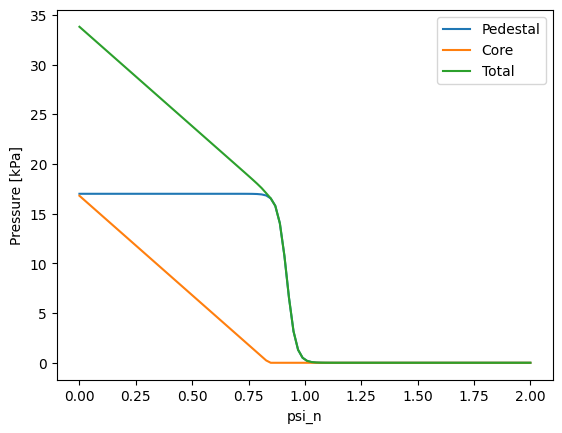

In [3]:
n_psi_n = 100
psi_n = np.linspace(0.0, 2.0, n_psi_n)

# Pedestal equation from "R.J. Groebner, and T.H. Osborne, Scaling studies of the high mode pedestal, POP, 1998"
pedestal_offset = 0.0  # pressure at LCFS [pascal]
pedestal_top = 17.0e3  # pressure at pedestal top [pascal]
psi_n_sym = 0.92  # middle of the pedestal [dimensionless]
pedestal_width = 0.08  # pedestal width in psi_n [dimensionless]
slope = 20.0e3  # slope of the core profile [pascal]

# Remember:
# `pedestal_top = a + b`
# `pedestal_offset = b - a`
a = (pedestal_top - pedestal_offset) / 2.0
b = (pedestal_top + pedestal_offset) / 2.0

# The "knee" (top) of the pedestal, where pedestal ends
psi_n_knee = psi_n_sym - pedestal_width

# Pedestal only pressure profile (flat into the core)
pressure_pdedesal = a * np.tanh(2.0 * (psi_n_sym - psi_n) / pedestal_width) + b

# Core profile
pressure_core = slope * (psi_n_knee - psi_n)
for i_psi_n in range(n_psi_n):
    if psi_n[i_psi_n] > psi_n_knee:
        pressure_core[i_psi_n] = 0.0

pressure = pressure_pdedesal + pressure_core

fig, ax = plt.subplots()
ax.plot(psi_n, pressure_pdedesal / 1e3, label="Pedestal")
ax.plot(psi_n, pressure_core / 1e3, label="Core")
ax.plot(psi_n, pressure / 1e3, label="Total")
ax.set_xlabel("psi_n")
ax.set_ylabel("Pressure [kPa]")
ax.legend()

In [4]:
# Define the p_prime and ff_prime functions for FreeGS
def p_prime_at_psi_n(psi_n: float) -> float:
    if psi_n < psi_n_knee:
        p_prime = slope * (2.0 * np.pi)
        return p_prime
    else:
        p_prime = a * (2.0 / pedestal_width) * (1.0 - np.tanh(2.0 * (psi_n_sym - psi_n) / pedestal_width) ** 2) * (2.0 * np.pi)
        if psi_n > 1.0:
            p_prime = 0.0
        return p_prime


def p_prime_function(psi_n):
    return np.vectorize(p_prime_at_psi_n)(psi_n)


def ff_prime_at_psi_n(psi_n: float) -> float:
    ff_prime = 120e3 * 1.4 * mu_0 * (1.0 - psi_n) * (2.0 * np.pi)
    if psi_n > 1.0:
        ff_prime = 0.0
    return ff_prime


def ff_prime_function(psi_n: float) -> float:
    return np.vectorize(ff_prime_at_psi_n)(psi_n)

(0.0, 2.0)

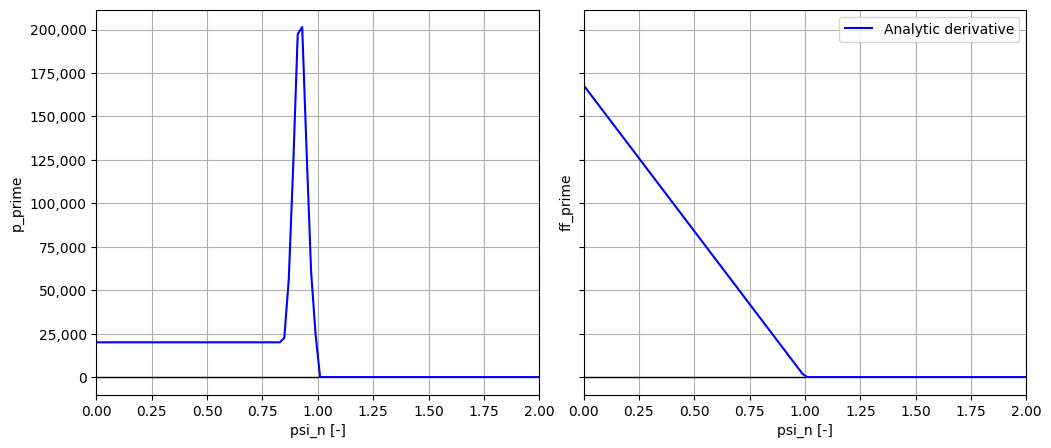

In [5]:
# Calculate the analytical derivatives
p_prime_from_function = np.zeros(n_psi_n)
ff_prime_from_function = np.zeros(n_psi_n)
for i_psi_n in range(n_psi_n):
    p_prime_from_function[i_psi_n] = p_prime_function(psi_n[i_psi_n])
    ff_prime_from_function[i_psi_n] = ff_prime_function(psi_n[i_psi_n]) / mu_0

fig, ax = gsfit_plotting.one_d_setup_source_function_plots.plot()
ax[0].plot(psi_n, p_prime_from_function / (2.0 * np.pi), linestyle="solid", color="blue", label="Analytic derivative")
ax[1].plot(psi_n, ff_prime_from_function / (2.0 * np.pi), linestyle="solid", color="blue", label="Analytic derivative")
ax[0].set_xlim(0.0, 2.0)

In [6]:
# Define what we want to reconstruct
pulseNo = 12050
times_to_reconstruct = 130.0e-3

In [7]:
# Set-up ST40 FreeGS PF coils
elmag_run_name = "RUN16"
elmag = GetData(11012050, f"ELMAG#{elmag_run_name}")

coils_r = elmag.get("COILS.R")
coils_z = elmag.get("COILS.Z")
coils_d_r = elmag.get("COILS.DR")
coils_d_z = elmag.get("COILS.DZ")
coil_names = elmag.get("COILS.COIL_NAMES")
fils2coils = elmag.get("COILS.FILS2COILS") == 1.0

psu2coil = GetData(12050, "PSU2COIL#RUN02")
time_experimental = psu2coil.get("TIME")

freegs_coils = []

for i_coil, coil_name in enumerate(coil_names):
    i_filaments = fils2coils[:, i_coil]
    coil_r = coils_r[i_filaments]
    coil_z = coils_z[i_filaments]
    coil_d_r = coils_d_r[i_filaments]
    coil_d_z = coils_d_z[i_filaments]
    n_turns = len(coil_r)
    # Skip the MCT, MCB, PSHT, and PSHB coils
    if coil_name == "MCT" or coil_name == "MCB" or coil_name == "PSHT" or coil_name == "PSHB":
        continue

    if coil_name == "SOL":
        current_experimental = psu2coil.get("PF.SOL.I")
        control = False
    elif coil_name == "DIVT" or coil_name == "DIVB":
        current_experimental = psu2coil.get("PF.DIV.I") * 1.0
        control = False
    elif coil_name == "BVUT":
        current_experimental = psu2coil.get("PF.BVUT.I") * 1.0
        control = True
    elif coil_name == "BVUB":
        current_experimental = psu2coil.get("PF.BVUT.I") * 1.0
        control = True
    elif coil_name == "BVL":
        current_experimental = psu2coil.get("PF.BVL.I") * 0.8  # Less BVL current to ensure the plasma is x-point diverted
        control = False
    else:
        current_experimental = psu2coil.get(f"PF.{coil_name[0:-1]}.I")
        control = False

    current = np.interp(times_to_reconstruct, time_experimental, current_experimental)
    coil = MultiCoil(coil_r, coil_z, current=current, control=control)
    freegs_coils.append((coil_name, coil))

# Set-up ST40 FreeGS magnetic sensors
# Initialize the sensors list
freegs_sensors = []

mag = GetData(pulseNo, "MAG#BEST")

# Add bp_probes
bp_names = mag.get("BPPROBE.ALL_000.NAMES")
for bp_name in bp_names:
    bp_name_short = bp_name.split("_")[1]
    angle = mag.get(f"BPPROBE.P{bp_name_short}.ANGLE")
    r = mag.get(f"BPPROBE.P{bp_name_short}.R")
    z = mag.get(f"BPPROBE.P{bp_name_short}.Z")

    # Add bp_sensors to the `tokamak` object
    freegs_sensor = freegs.machine.PoloidalFieldSensor(
        R=r,
        Z=z,
        theta=angle,
        name=f"P{bp_name_short}",
    )
    freegs_sensors.append(freegs_sensor)

# Add flux loop sensors
fl_names = mag.get("FLOOP.ALL.NAMES")
for fl_name in fl_names:
    fl_name_short = fl_name.split("_")[1]
    r = mag.get(f"FLOOP.L{fl_name_short}.R")
    z = mag.get(f"FLOOP.L{fl_name_short}.Z")

    # Add bp_sensors to the `tokamak` object
    freegs_sensor = freegs.machine.FluxLoopSensor(
        R=r,
        Z=z,
        name=f"L{fl_name_short}",
    )
    freegs_sensors.append(freegs_sensor)

# Plasma current
gsfit_database = GetData(12050, "GSFIT#TEST12")
time_gsfit_database = gsfit_database.get("TIME")
ip_experimental = gsfit_database.get("GLOBAL.IP")
ip = np.interp(times_to_reconstruct, time_gsfit_database, ip_experimental)

# Set-up ST40 FreeGS Wall
r_limit_pts = elmag.get("LIMITER.LIMIT_PTS.R")
z_limit_pts = elmag.get("LIMITER.LIMIT_PTS.Z")
freegs_wall = Wall(r_limit_pts, z_limit_pts)

# Set-up ST40 FreeGS Machine
freegs_tokamak = Machine(
    coils=freegs_coils,
    wall=freegs_wall,
    sensors=freegs_sensors,
)

# Set-up ST40 FreeGS Equilibrium
freegs_eq = freegs.Equilibrium(
    tokamak=freegs_tokamak,
    Rmin=0.1,
    Rmax=1.0,
    Zmin=-1.0,
    Zmax=1.0,
    nx=129,
    ny=257,
    current=ip,
)

# Set-up ST40 FreeGS plasma profiles
profiles = freegs.jtor.ProfilesPprimeFfprime(
    p_prime_function,
    ff_prime_function,
    fvac=1.8 * 0.4,  # vacuum f = R*Bt
)

# To avoid the VDE, we need to add constraints
xpoints = [
    (0.35, -0.532),  # (R,Z) locations of X-points
    (0.35, 0.535),  # (R,Z) locations of X-points
]
constrain = freegs.control.constrain(xpoints)

# Solve the Grad-Shafranov equation
freegs.solve(
    freegs_eq,  # The equilibrium object
    profiles,
    constrain=constrain,  # Forward solver, no constraints
    show=False,  # Don't plot results while solving
    convergenceInfo=True,
    rtol=5.0e-3,  # relative tolerance (default 1e-3)
    atol=1.0e-5,  # absolute tolerance (default 1e-10)
    blend=0.75,
    maxits=100,
)

# Take measurements
freegs_eq.tokamak.takeMeasurements(eq=freegs_eq)

# Plot the equilibrium solution
# freegs_eq.plot() # we will plot in next cell with our own plotting code

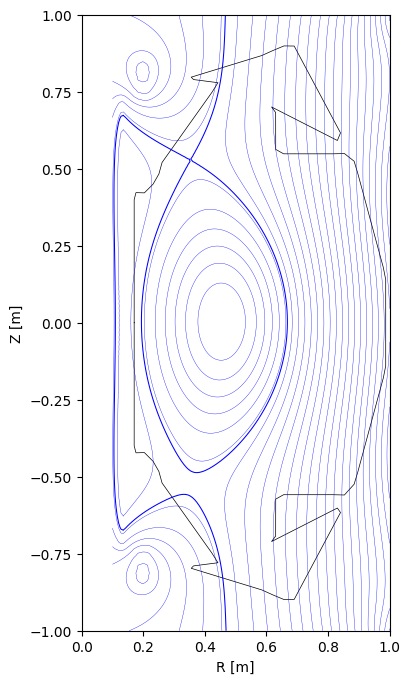

In [8]:
# Compare the FreeGS equilibrium to the GSFit equilibrium
freegs_r = freegs_eq.R
freegs_z = freegs_eq.Z
freegs_r_1d = freegs_eq.R_1D
freegs_z_1d = freegs_eq.Z_1D
freegs_psi = freegs_eq.psiRZ(freegs_r, freegs_z).T * (2.0 * np.pi)  # Convert from Wb/(2*pi) to Wb
freegs_psi_b = freegs_eq.psi_bndry * (2.0 * np.pi)

# Setup figure and axes
fig, ax = gsfit_plotting.two_d_setup_plots.plot()
ax.plot(r_limit_pts, z_limit_pts, color="black", linewidth=0.5)

ax.contour(freegs_r_1d, freegs_z_1d, freegs_psi, levels=30, colors="blue", linewidths=0.25, linestyles="solid")
ax.contour(freegs_r_1d, freegs_z_1d, freegs_psi, [freegs_psi_b], colors="blue", linewidths=0.75, linestyles="solid")

In [9]:
gsfit_controller = Gsfit(
    pulseNo=None,
    run_name="test_01",
    run_description="using FreeGS to generate measurements",
    settings_path="st40_all_magnetic_sensors_working",
    write_to_mds=False,
)
gsfit_controller.settings["GSFIT_code_settings.json"]["database_reader"]["method"] = "freegs"
gsfit_controller.settings["GSFIT_code_settings.json"]["timeslices"]["method"] = "user_defined"
gsfit_controller.settings["GSFIT_code_settings.json"]["timeslices"]["user_defined"] = [0.5]

gsfit_controller.run(time=np.array([0.0, 1.0]), freegs_eqs=[freegs_eq, freegs_eq])

2026-05-09 10:51:16  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "GSFIT_code_settings.json"
2026-05-09 10:51:16  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "passive_dof_regularisation.json"
2026-05-09 10:51:16  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_bp_probe.json"
2026-05-09 10:51:16  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_dialoop.json"
2026-05-09 10:51:16  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_flux_loops.json"
2026-05-09 10:51:16  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_isoflux.json"
2026-05-09 10:51:16  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_pressure.json"
2026-05-09 10:51:16  |  GSFI

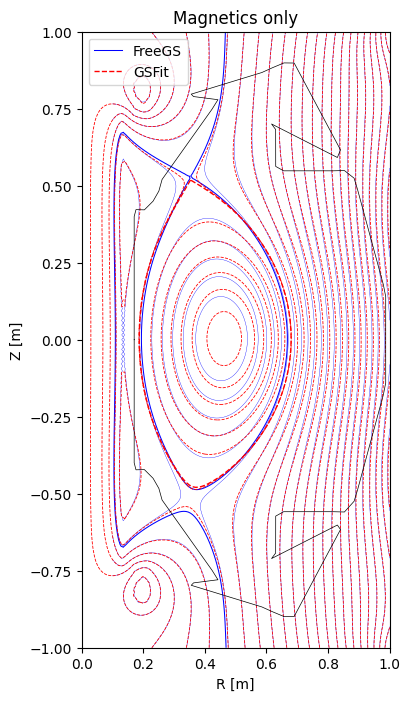

In [10]:
# Compare the FreeGS equilibrium to the GSFit equilibrium
freegs_r = freegs_eq.R
freegs_z = freegs_eq.Z
freegs_r_1d = freegs_eq.R_1D
freegs_z_1d = freegs_eq.Z_1D
freegs_psi = freegs_eq.psiRZ(freegs_r, freegs_z).T * (2.0 * np.pi)  # Convert from Wb/(2*pi) to Wb
freegs_psi_b = freegs_eq.psi_bndry * (2.0 * np.pi)

# Note: we will plot with the same `psi_n_levels` for FreeGS and GSFit
psi_n_levels = np.linspace(np.min(freegs_psi), np.max(freegs_psi), 25)

# Setup figure and axes
fig, ax = gsfit_plotting.two_d_setup_plots.plot()
ax.set_title("Magnetics only")

# FreeGS
ax.contour(freegs_r_1d, freegs_z_1d, freegs_psi, levels=psi_n_levels, colors="blue", linewidths=0.25, linestyles="solid")
ax.contour(freegs_r_1d, freegs_z_1d, freegs_psi, [freegs_psi_b], colors="blue", linewidths=0.75, linestyles="solid")
ax.plot([], [], color="blue", linewidth=0.75, linestyle="solid", label="FreeGS")

# GSFit
gsfit_plotting.two_d_plasma.plot(gsfit_controller, ax, 500e-3, color="red", psi_n_levels=psi_n_levels)
gsfit_plotting.two_d_limiter.plot(gsfit_controller, ax)

ax.legend()

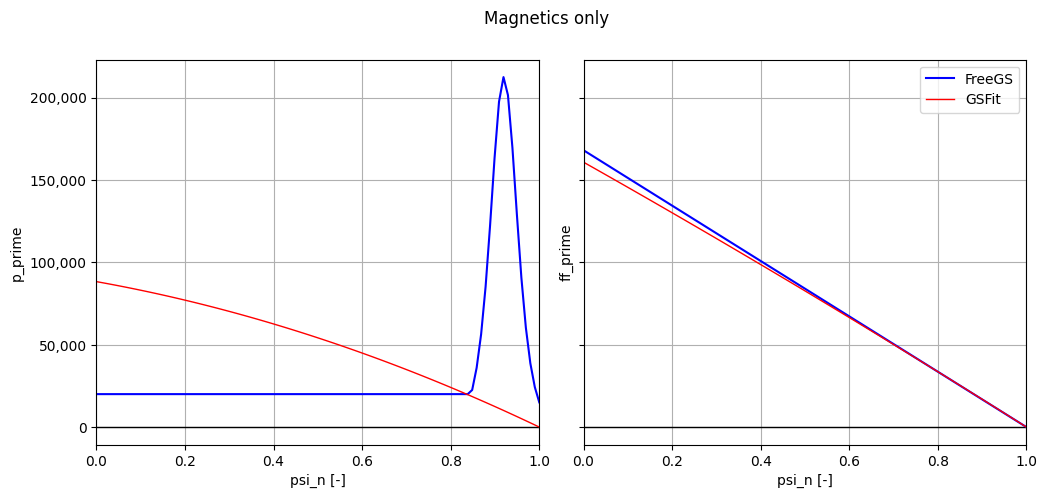

In [11]:
# Setup figure and axes
fig, ax = gsfit_plotting.one_d_setup_source_function_plots.plot()
fig.suptitle("Magnetics only")

# Plot FreeGS
psi_n = np.linspace(0.0, 1.0, 100)
freegs_p_prime = freegs_eq.pprime(psi_n)
freegs_ff_prime = freegs_eq.ffprime(psi_n)
ax[0].plot(psi_n, freegs_p_prime / (2.0 * np.pi), label="FreeGS", color="blue")
ax[1].plot(psi_n, freegs_ff_prime / (2.0 * np.pi * mu_0), label="FreeGS", color="blue")

# Plot GSFit
gsfit_plotting.one_d_p_prime.plot(gsfit_controller, ax[0], 500e-3, color="red")
gsfit_plotting.one_d_ff_prime.plot(gsfit_controller, ax[1], 500e-3, color="red")

In [12]:
# Calculate the FreeGS pressure on the mid-plane
freegs_mid_plane_r = freegs_eq.R_1D
freegs_mid_plane_z = 0.0 * freegs_mid_plane_r
freegs_mid_plane_psi_n = freegs_eq.psiNRZ(freegs_mid_plane_r, freegs_mid_plane_z)
freegs_mid_plane_pressure = freegs_eq.pressure(freegs_mid_plane_psi_n)

In [13]:
conn = mdsthin.Connection("smaug")
conn.openTree("TS", 12050)
ts_r = conn.get("\\TS::TOP.BEST:R").data().astype(np.float64)
# TODO: we should really use the `ts_z` location, which is ~1mm off the mid-plane (but for synthetic data this makes no difference, so long as we are consistent)
# ts_z = conn.get("\\TS::TOP.BEST:Z").data().astype(np.float64)
ts_n = len(ts_r)
ts_z = np.zeros(ts_n)

Text(0.5, 1.0, 'Magnetics only')

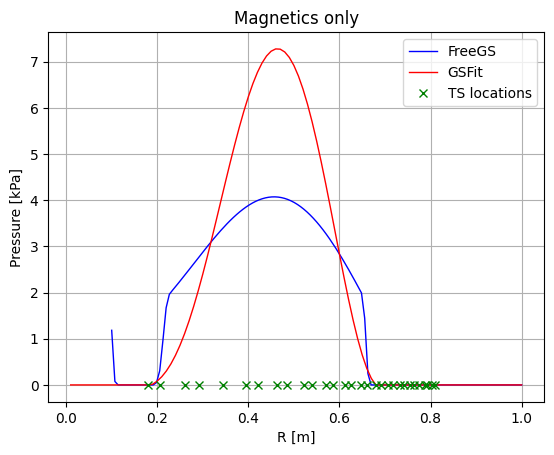

In [14]:
plasma = gsfit_controller.plasma
r = plasma.get_array1(["profiles", "mid_plane", "r"])
pressure = plasma.get_array2(["profiles", "mid_plane", "p"])[0, :]

fig, ax = plt.subplots()
ax.grid()
ax.plot(freegs_mid_plane_r, freegs_mid_plane_pressure / 1e3, color="blue", linewidth=1.0, label="FreeGS")
ax.plot(r, pressure / 1e3, color="red", linewidth=1.0, linestyle="solid", label="GSFit")
ax.plot(ts_r, np.zeros_like(ts_r), marker="x", linestyle="none", color="green", label="TS locations")
ax.set_xlabel("R [m]")
ax.set_ylabel("Pressure [kPa]")
ax.legend()
ax.set_title("Magnetics only")

2026-05-09 10:51:58  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "GSFIT_code_settings.json"
2026-05-09 10:51:58  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "passive_dof_regularisation.json"
2026-05-09 10:51:58  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_bp_probe.json"
2026-05-09 10:51:58  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_dialoop.json"
2026-05-09 10:51:58  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_flux_loops.json"
2026-05-09 10:51:58  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_isoflux.json"
2026-05-09 10:51:58  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_pressure.json"
2026-05-09 10:51:58  |  GSFI

Text(0, 0.5, 'Pressure [kPa]')

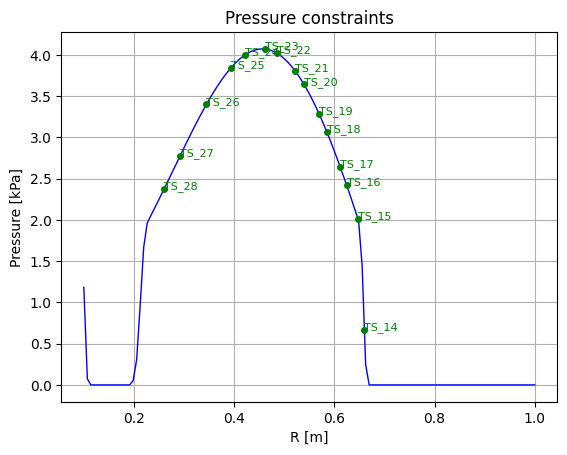

In [15]:
gsfit_controller_pressure_constrained = Gsfit(
    pulseNo=None,
    run_name="test_01",
    run_description="using FreeGS to generate measurements",
    settings_path="st40_all_magnetic_sensors_working",
    write_to_mds=False,
)
gsfit_controller_pressure_constrained.settings["GSFIT_code_settings.json"]["database_reader"]["method"] = "freegs"
gsfit_controller_pressure_constrained.settings["GSFIT_code_settings.json"]["timeslices"]["method"] = "user_defined"
gsfit_controller_pressure_constrained.settings["GSFIT_code_settings.json"]["timeslices"]["user_defined"] = [0.5]

# Interpolate the pressure at the TS locations; don't add sensors where the pressure is < 0.5 kPa, which typically have high error bars
pressure_sensors = gsfit_rs.Pressure()
for i_ts in range(ts_n):
    ts_pressure = np.interp(ts_r[i_ts], freegs_mid_plane_r, freegs_mid_plane_pressure)
    if ts_pressure > 0.5e3:
        pressure_sensors.add_sensor(
            name=f"TS_{i_ts + 1}",
            geometry_r=ts_r[i_ts],
            geometry_z=ts_z[i_ts],
            fit_settings_comment="",
            fit_settings_expected_value=2e3,
            fit_settings_include=True,
            fit_settings_weight=10.0,
            time=np.array([0.0, 1.0]),
            measured=np.array([ts_pressure, ts_pressure]),
        )

fig, ax = plt.subplots()
ax.set_title("Pressure constraints")
ax.grid()
ax.plot(freegs_mid_plane_r, freegs_mid_plane_pressure / 1e3, color="blue", linewidth=1.0)
for sensor_name in pressure_sensors.keys():
    ts_r_local = pressure_sensors.get_f64([sensor_name, "geometry", "r"])
    ts_pressure = pressure_sensors.get_array1([sensor_name, "pressure", "experimental", "value"])[0]
    ax.plot(ts_r_local, ts_pressure / 1e3, marker="o", markersize=4.0, linestyle="none", color="green")
    ax.text(ts_r_local, ts_pressure / 1e3, sensor_name, fontsize=8, color="green")
ax.set_xlabel("R [m]")
ax.set_ylabel("Pressure [kPa]")

In [16]:
# Use splines for p_prime
gsfit_controller_pressure_constrained.settings["source_function_p_prime.json"]["method"] = "tensioned_cubic_b_spline"

# Standard set-up
gsfit_controller_pressure_constrained.set_environment_variables()
gsfit_controller_pressure_constrained.setup_timeslices()
gsfit_controller_pressure_constrained.setup_objects(time=np.array([0.0, 1.0]), freegs_eqs=[freegs_eq, freegs_eq])

# Add the custom pressure_sensors into the `gsfit_controller` object
gsfit_controller_pressure_constrained.pressure_sensors = pressure_sensors

# Calculate the Greens functions for all permutations between current source objects and sensors.
gsfit_controller_pressure_constrained.calculate_greens()

# Solve the GS equation
gsfit_controller_pressure_constrained.inverse_solver_rust()

2026-05-09 10:51:58  |  GSFIT  |  gsfit.py:290                           |  INFO  |  `coils`  initialised;  0.16ms
2026-05-09 10:51:58  |  GSFIT  |  gsfit.py:295                           |  INFO  |  `bp_probes` initialised;  0.27ms
2026-05-09 10:51:58  |  GSFIT  |  gsfit.py:300                           |  INFO  |  `flux_loops` initialised;  0.25ms
2026-05-09 10:51:58  |  GSFIT  |  gsfit.py:305                           |  INFO  |  `rogowski_coils` initialised;  0.04ms
2026-05-09 10:51:58  |  GSFIT  |  gsfit.py:310                           |  INFO  |  `passives` initialised;  0.01ms
2026-05-09 10:51:58  |  GSFIT  |  gsfit.py:315                           |  INFO  |  `plasma` initialised;  166.73ms
2026-05-09 10:51:58  |  GSFIT  |  gsfit.py:321                           |  INFO  |  `isoflux` initialised;  0.01ms
2026-05-09 10:51:58  |  GSFIT  |  gsfit.py:326                           |  INFO  |  `isoflux_boundary` initialised;  0.01ms
2026-05-09 10:51:58  |  GSFIT  |  gsfit.py:331    

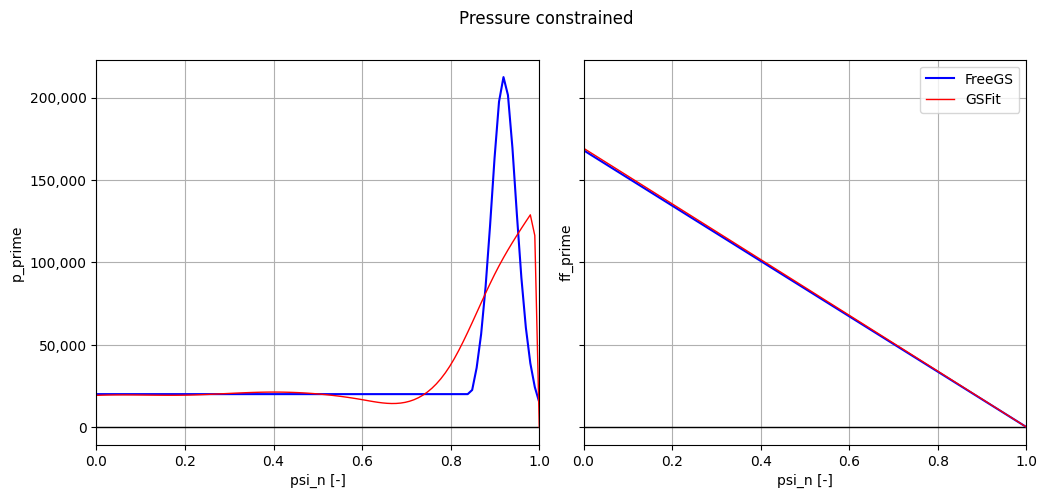

In [17]:
# Setup figure and axes
fig, ax = gsfit_plotting.one_d_setup_source_function_plots.plot()
fig.suptitle("Pressure constrained")

# Plot FreeGS
freegs_p_prime = freegs_eq.pprime(psi_n)
freegs_ff_prime = freegs_eq.ffprime(psi_n)
ax[0].plot(psi_n, freegs_p_prime / (2.0 * np.pi), label="FreeGS", color="blue")
ax[1].plot(psi_n, freegs_ff_prime / (2.0 * np.pi * mu_0), label="FreeGS", color="blue")

# Plot GSFit
gsfit_plotting.one_d_p_prime.plot(gsfit_controller_pressure_constrained, ax[0], 500e-3, color="red")
gsfit_plotting.one_d_ff_prime.plot(gsfit_controller_pressure_constrained, ax[1], 500e-3, color="red")

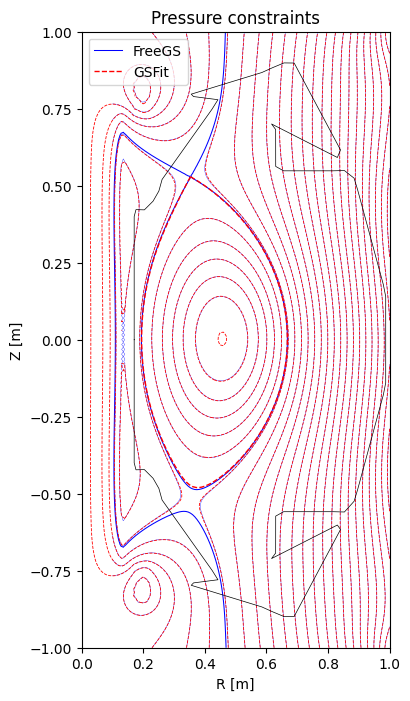

In [18]:
# Compare the FreeGS equilibrium to the GSFit equilibrium
freegs_r = freegs_eq.R
freegs_z = freegs_eq.Z
freegs_r_1d = freegs_eq.R_1D
freegs_z_1d = freegs_eq.Z_1D
freegs_psi = freegs_eq.psiRZ(freegs_r, freegs_z).T * (2.0 * np.pi)  # Convert from Wb/(2*pi) to Wb
freegs_psi_b = freegs_eq.psi_bndry * (2.0 * np.pi)

# We will plot with the same `psi_n_levels` for FreeGS and GSFit
psi_n_levels = np.linspace(np.min(freegs_psi), np.max(freegs_psi), 25)

# Setup figure and axes
fig, ax = gsfit_plotting.two_d_setup_plots.plot()
ax.set_title("Pressure constraints")

# FreeGS
ax.contour(freegs_r_1d, freegs_z_1d, freegs_psi, levels=psi_n_levels, colors="blue", linewidths=0.25, linestyles="solid")
ax.contour(freegs_r_1d, freegs_z_1d, freegs_psi, [freegs_psi_b], colors="blue", linewidths=0.75, linestyles="solid")
ax.plot([], [], color="blue", linewidth=0.75, label="FreeGS")

# GSFit
gsfit_plotting.two_d_plasma.plot(gsfit_controller_pressure_constrained, ax, 500e-3, color="red", psi_n_levels=psi_n_levels)
gsfit_plotting.two_d_limiter.plot(gsfit_controller_pressure_constrained, ax)

ax.legend()

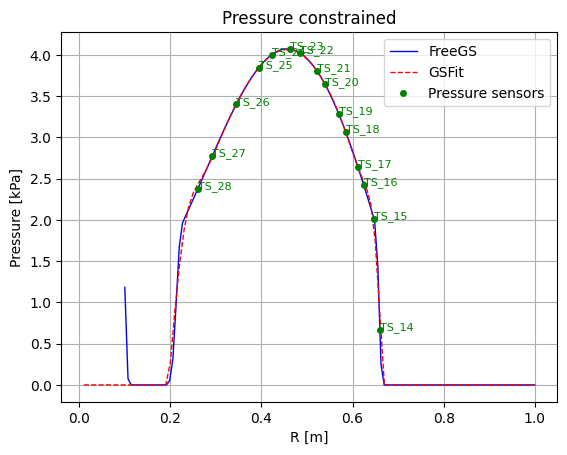

In [19]:
r = gsfit_controller_pressure_constrained.plasma.get_array1(["profiles", "mid_plane", "r"])
pressure = gsfit_controller_pressure_constrained.plasma.get_array2(["profiles", "mid_plane", "p"])[0, :]

fig, ax = plt.subplots()
ax.grid()
ax.set_title("Pressure constrained")
ax.set_xlabel("R [m]")
ax.set_ylabel("Pressure [kPa]")

# Plot FreeGS
ax.plot(freegs_mid_plane_r, freegs_mid_plane_pressure / 1e3, linewidth=1.0, color="blue", label="FreeGS")

# Plot GSFit
ax.plot(r, pressure / 1e3, linewidth=1.0, linestyle="--", color="red", label="GSFit")

# Plot the pressure at TS locations
for sensor_name in pressure_sensors.keys():
    ts_r_local = pressure_sensors.get_f64([sensor_name, "geometry", "r"])
    ts_pressure = pressure_sensors.get_array1([sensor_name, "pressure", "experimental", "value"])[0]
    ax.plot(ts_r_local, ts_pressure / 1e3, marker="o", markersize=4.0, linestyle="none", color="green")
    ax.text(ts_r_local, ts_pressure / 1e3, sensor_name, fontsize=8, color="green")
ax.plot([], [], marker="o", markersize=4.0, linestyle="none", color="green", label="Pressure sensors")

ax.legend()

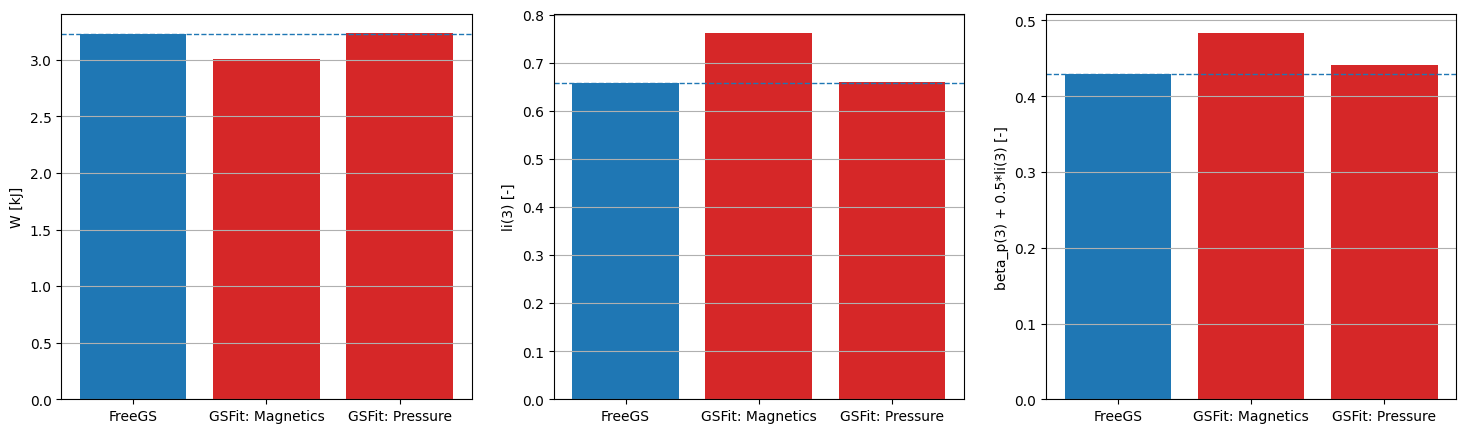

In [20]:
names = ["FreeGS", "GSFit: Magnetics", "GSFit: Pressure"]
w_mhd = [
    freegs_eq.w_th() / 1e3,
    gsfit_controller.plasma.get_array1(["global", "w_mhd"])[0] / 1e3,
    gsfit_controller_pressure_constrained.plasma.get_array1(["global", "w_mhd"])[0] / 1e3,
]
li_3 = [
    freegs_eq.internalInductance3(),
    gsfit_controller.plasma.get_array1(["global", "li_3"])[0],
    gsfit_controller_pressure_constrained.plasma.get_array1(["global", "li_3"])[0]
]
beta_p_3_plus_0p5_li_3 = [
    freegs_eq.poloidalBeta3() + 0.5 * freegs_eq.internalInductance3(),
    gsfit_controller.plasma.get_array1(["global", "beta_p_3"])[0] + 0.5 * gsfit_controller.plasma.get_array1(["global", "li_3"])[0],
    gsfit_controller_pressure_constrained.plasma.get_array1(["global", "beta_p_3"])[0] + 0.5 * gsfit_controller_pressure_constrained.plasma.get_array1(["global", "li_3"])[0]
]


fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].bar(names, w_mhd)
ax[0].set_ylabel("W [kJ]")
ax[0].grid(axis="y")
bar_colors = ["tab:blue", "tab:red", "tab:red"]
for patch, color in zip(ax[0].patches, bar_colors):
    patch.set_facecolor(color)
ax[0].axhline(y=w_mhd[0], color="tab:blue", linestyle="--", linewidth=1.0)

ax[1].bar(names, li_3)
ax[1].set_ylabel("li(3) [-]")
ax[1].grid(axis="y")
bar_colors = ["tab:blue", "tab:red", "tab:red"]
for patch, color in zip(ax[1].patches, bar_colors):
    patch.set_facecolor(color)
ax[1].axhline(y=li_3[0], color="tab:blue", linestyle="--", linewidth=1.0)

ax[2].bar(names, beta_p_3_plus_0p5_li_3)
ax[2].set_ylabel("beta_p(3) + 0.5*li(3) [-]")
ax[2].grid(axis="y")
bar_colors = ["tab:blue", "tab:red", "tab:red"]
for patch, color in zip(ax[2].patches, bar_colors):
    patch.set_facecolor(color)
ax[2].axhline(y=beta_p_3_plus_0p5_li_3[0], color="tab:blue", linestyle="--", linewidth=1.0)

In [21]:
print(datetime.now())

2026-05-09 10:56:17.244269


A large fraction of fast particles can cause source function profiles to have a non-monotonic shape within the core.